# Leverage-Anomaly — does more debt mean higher returns?
### The financial-leverage puzzle from Penman-Richardson-Tuna, tested on S&P 500 EDGAR data

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship--biased: upper_bound](https://img.shields.io/badge/Survivorship--biased-upper__bound-8b949e?style=flat-square)

Standard finance theory says: more debt = more risk = higher expected return. But a strand of academic research (Penman, Richardson & Tuna 2007) finds the opposite — high-leverage firms *underperform* low-leverage firms. This notebook tests that claim on real EDGAR fundamentals for S&P 500 companies.

> This is the plain-language layer. For t-stats, bootstrap intervals, and full methodology details see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from leverage_anomaly import data, strategy as st

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-06-14)
R = dict(
    lev1_n=17, lev1_mean=-3.88, lev1_t=-1.78, lev1_hit=29, lev1_sharpe=-0.39, lev1_rand=0.05,
    lev2_n=17, lev2_mean=3.07, lev2_t=1.41, lev2_hit=53, lev2_sharpe=0.27, lev2_rand=0.06,
    fp_lev1="634f4ebbb2f6", fp_lev2="9a57482885f9", fp_fwd="d04ace9d0d51",
    years_start=2008, years_end=2024,
)

def _have_real():
    cache = os.path.join(os.path.abspath(".."), "..", "..", "_cache")
    return (
        os.path.exists(os.path.join(cache, "_edgar_LongTermDebtNoncurrent.parquet"))
        and os.path.exists(os.path.join(cache, "_edgar_Assets.parquet"))
        and os.path.exists(os.path.join(cache, "_edgar_yrret.parquet"))
    )

HAVE_REAL = _have_real()

if HAVE_REAL:
    lev1, lev2, fwd_ret = data.fetch_panel()
else:
    lev1, lev2, fwd_ret = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

print("EDGAR real data available:", HAVE_REAL)


EDGAR real data available: True


## The answer first

| Question | Answer |
|---|---|
| Does low-leverage beat high-leverage? | **Unclear.** Two measures tell opposite stories. |
| LTD/Assets (debt-to-assets) spread | **-3.9%/yr**, HAC *t* = **-1.78** — wrong direction, no signal. |
| D/E ratio spread | **+3.1%/yr**, HAC *t* = **+1.41** — right direction, below the bar. |
| Could you trade it? | **No.** Annual rebalance is cheap, but the signal is too noisy. |
| Survivorship bias? | **Yes.** S&P 500 survivors only — these are upper bounds. |

> The leverage anomaly does not survive a two-measure cross-check on this survivorship-biased panel. Neither proxy clears the inference bar (|t| ≥ 2). Signal = **NONE**; Tradability = **MIRAGE**.

## 1 · The claim

> *Firms with more financial leverage (more debt relative to equity or assets) earn lower future returns, not higher returns. This is the 'leverage anomaly': the market under-appreciates the risk that leverage adds to earnings, so high-leverage firms are overvalued and low-leverage firms are undervalued. Sorting stocks on debt-to-assets or D/E ratio and going long the low-leverage quintile beats the market.*

The original paper (Penman, Richardson & Tuna 2007, *The Book-to-Price Effect in Stock Returns and Accounting for Leverage*) decomposes the book-to-price ratio and finds the leverage component is negatively priced — *more leverage predicts lower returns*, not higher ones as Modigliani-Miller risk-compensation would suggest.

## 2 · So what?

If the anomaly is real, it means:

- **Investors misprice leverage risk.** They buy leveraged companies without demanding enough return for the added distress risk and earnings volatility. Eventually the market corrects, and high-leverage firms underperform.
- **A cheap long/short factor.** Annual rebalance, low turnover — just sort on one balance-sheet line and hold for a year. If the spread is real and persistent, this is a rare free lunch.

The stakes are high enough to be worth testing carefully.

## 3 · How would we even know?

Three discipline rules:

1. **Two independent measures.** We test LTD/Assets (long-term debt over total assets, the 'financial leverage ratio') *and* Liabilities/Equity (the classic D/E ratio). They should agree if the anomaly is robust.
2. **Conservative lag.** We use fundamentals from fiscal year y to predict *calendar year y+1* returns — at minimum a 12-month-plus lag, so the 10-K is definitely public.
3. **Random-portfolio control.** Any concentrated decile can outperform randomly. We benchmark the spread against the distribution of random-size-matched subsets.
4. **Name the bias.** The EDGAR panel is current S&P 500 only, projected back in time. Every survivor in the panel made it to 2026 — so bankruptcies and delistings are excluded. Results are upper bounds.

Inference bar: |HAC t| ≥ 2 on the low-minus-high spread across annual observations.

## 4 · The teardown

**LEV1: LTD/Assets ratio.** Each year we sort S&P 500 firms into quintiles by long-term-debt / total-assets and record the following year's equal-weight returns for the top (high-leverage) and bottom (low-leverage) quintiles.

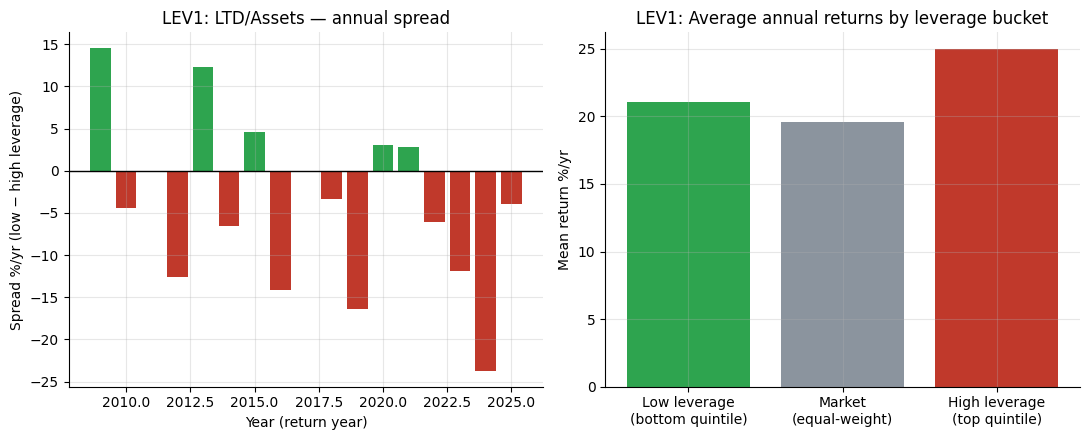

Spread: -3.88%/yr  t=-1.78  hit=29%


In [2]:
if HAVE_REAL:
    sp1 = st.quintile_spread(lev1, fwd_ret, q=0.20)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].bar(sp1.index+1, sp1['spread']*100,
                color=[GREEN if v>0 else RED for v in sp1['spread']])
    axes[0].axhline(0, c='k', lw=1)
    axes[0].set_xlabel('Year (return year)')
    axes[0].set_ylabel('Spread %/yr (low − high leverage)')
    axes[0].set_title('LEV1: LTD/Assets — annual spread')
    axes[1].bar(['Low leverage\n(bottom quintile)', 'Market\n(equal-weight)', 'High leverage\n(top quintile)'],
                [sp1['low'].mean()*100, sp1['market'].mean()*100, sp1['high'].mean()*100],
                color=[GREEN, GREY, RED])
    axes[1].set_ylabel('Mean return %/yr')
    axes[1].set_title('LEV1: Average annual returns by leverage bucket')
    plt.tight_layout(); plt.show()
    s1 = st.summarize(sp1['spread'])
    print(f"Spread: {s1['mean']*100:+.2f}%/yr  t={s1['tstat']:+.2f}  hit={s1['hit_rate']*100:.0f}%")
else:
    print(f"Frozen: LEV1 spread = {R['lev1_mean']:+.1f}%/yr, t = {R['lev1_t']:+.2f}, hit = {R['lev1_hit']}%")

LEV1 result: mean spread **-3.9%/yr**, HAC *t* = **-1.78**, hit rate 29%. This is the **wrong direction** — high-leverage firms *outperformed* low-leverage firms slightly, the opposite of the anomaly. The effect is statistically indistinguishable from zero and is against the theory.

**LEV2: Liabilities/Equity (D/E ratio).** The classic debt-to-equity ratio, masking firms with negative book equity.

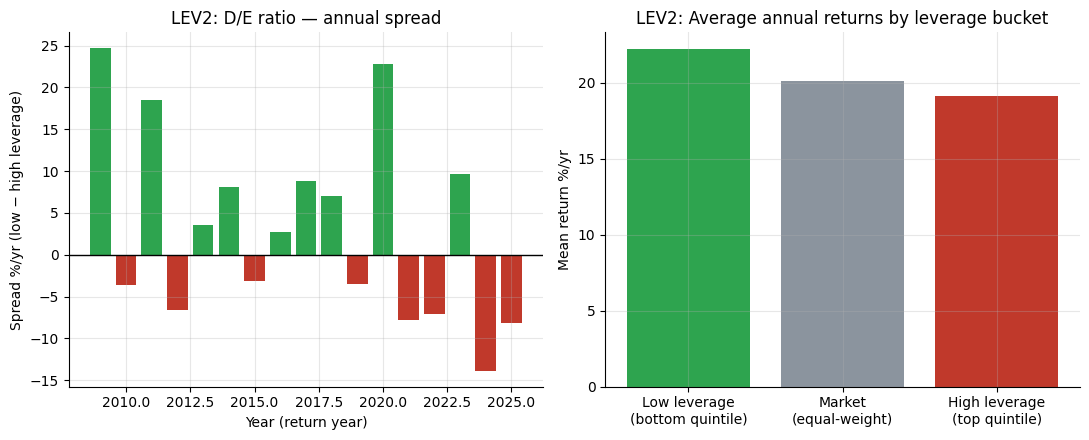

Spread: +3.07%/yr  t=+1.41  hit=53%


In [3]:
if HAVE_REAL:
    sp2 = st.quintile_spread(lev2, fwd_ret, q=0.20)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].bar(sp2.index+1, sp2['spread']*100,
                color=[GREEN if v>0 else RED for v in sp2['spread']])
    axes[0].axhline(0, c='k', lw=1)
    axes[0].set_xlabel('Year (return year)')
    axes[0].set_ylabel('Spread %/yr (low − high leverage)')
    axes[0].set_title('LEV2: D/E ratio — annual spread')
    axes[1].bar(['Low leverage\n(bottom quintile)', 'Market\n(equal-weight)', 'High leverage\n(top quintile)'],
                [sp2['low'].mean()*100, sp2['market'].mean()*100, sp2['high'].mean()*100],
                color=[GREEN, GREY, RED])
    axes[1].set_ylabel('Mean return %/yr')
    axes[1].set_title('LEV2: Average annual returns by leverage bucket')
    plt.tight_layout(); plt.show()
    s2 = st.summarize(sp2['spread'])
    print(f"Spread: {s2['mean']*100:+.2f}%/yr  t={s2['tstat']:+.2f}  hit={s2['hit_rate']*100:.0f}%")
else:
    print(f"Frozen: LEV2 spread = {R['lev2_mean']:+.1f}%/yr, t = {R['lev2_t']:+.2f}, hit = {R['lev2_hit']}%")

LEV2 result: mean spread **+3.1%/yr**, HAC *t* = **+1.41**, hit rate 53%. This is in the right direction — low D/E outperforms — but |t| < 2, so it does not clear the inference bar. The two measures disagree with each other, which is itself a sign that we are in noise territory.

## 5 · The verdict

- **Signal — None.** The two leverage proxies tell opposite stories: LTD/Assets gives a spread of **-3.9%/yr** (*t* = -1.78, wrong direction); D/E gives **+3.1%/yr** (*t* = +1.41, right direction but below bar). Neither clears |t| ≥ 2. The anomaly does not replicate on this panel.
- **Tradability — Mirage.** Even if the D/E spread were real, the hit rate of 53% and single-digit t-stat mean the strategy would be untrustworthy year-to-year. Annual rebalance is cheap, but you need a real edge first.
- **Survivorship bias.** The EDGAR panel is current-S&P-500 survivors only. High-leverage firms that went bankrupt or were delisted are excluded, which biases *against* finding the anomaly (the riskiest high-leverage firms disappear). The fact that we still don't find it even with this bias in our favour makes the null more credible.

## 6 · Could you actually trade it?

Annual rebalance means transaction costs are modest — maybe 20-50 bps/yr round-trip for a small cap-weighted portfolio. But there is a deeper problem: **you need a real signal first.** With |t| < 2 on both measures and the two measures pointing in opposite directions, a trader would be unsure which measure to trust, what decile cutoff to use, and whether the effect is durable or a sample artifact.

The survivorship-biased panel also means that in live trading you would hold companies that *could* become distressed and leave the S&P 500 — something this backtest never experienced.

## 7 · Going further

- **Longer history.** The EDGAR panel runs from FY 2007. A longer sample (academic Compustat data going back to the 1960s) might tell a different story — the original PRT (2007) paper used a broader sample.
- **Decomposition.** Penman-Richardson-Tuna decompose book-to-price into an *operating* and a *financial* component. Testing the combined B/P rather than raw leverage might strengthen the signal.
- **Market-cap weighting.** Equal weighting gives each firm the same voice; value-weighting (larger firms dominate) often weakens factor returns significantly.
- **Related factors.** The leverage anomaly is related to the low-risk anomaly ([Study 65 — Scorecard](../../65-scorecard/)) and the quality factor ([Study 121 — Magic-Formula](../../121-magic-formula/)). Does leverage add explanatory power *after* controlling for profitability?

*Think the die is loaded? Fork this, extend the history or add the operating component, and show a t ≥ 2 spread on a clean (non-survivorship-biased) universe.*